Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


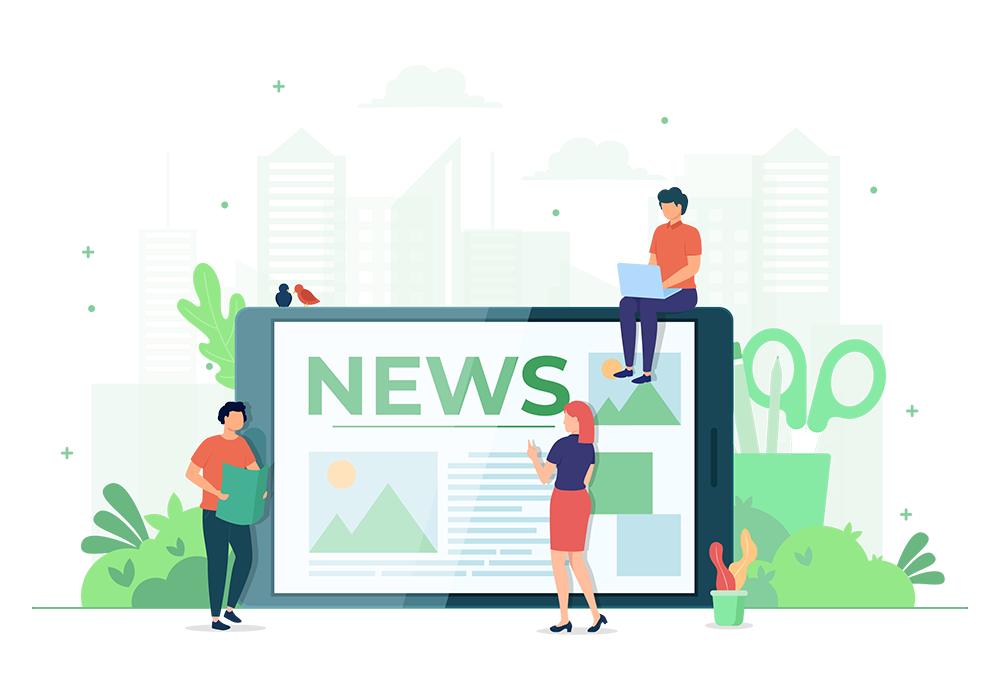

In [19]:
# mounting goodle drive , code to import the image
from google.colab import drive
drive.mount('/content/drive')
from IPython.display import Image
Image('/content/drive/My Drive/Colab Notebooks/AppliedStat/news.png')

#Background
E-news Express, an online news portal, aims to expand its business by acquiring new subscribers. With every visitor to the website taking certain actions based on their interest, the company plans to analyze these actions to understand user interests and determine how to drive better engagement. The executives at E-news Express believe that there has been a decline in new monthly subscribers compared to the past year because the current webpage is not designed well enough in terms of the outline & recommended content to keep customers engaged long enough to decide to subscribe.

#Objective
The design team of the company has researched and created a new landing page that has a new outline & more relevant content compared to the old page. To test the effectiveness of the new landing page in gathering new subscribers, the Data Science team experimented by randomly selecting 100 users and dividing them equally into two groups. The existing landing page was served to the first group (control group) and the new landing page to the second group (treatment group). Data regarding the interaction of users in both groups with the two versions of the landing page was collected.

[Companies often analyze user responses to two variants of a product to decide which of the two variants is more effective. This experimental technique, known as A/B testing, is used to determine whether a new feature attracts users based on a chosen metric.]

Being a data scientist in E-news Express, you have been asked to explore the data and perform a statistical analysis (at a significance level of 5%) to determine the effectiveness of the new landing page in gathering new

subscribers for the news portal,

#By answering the following questions:


---


1) Do the users spend more time on the new landing page than on the existing
landing page?

2) Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

3) Does the converted status depend on the preferred language?

4) Is the time spent on the new page the same for the different language users?

#Exploratory Data Analysis

In [55]:
#Libraries to help and manipulate data
import pandas as pd
import numpy as np
#Libraries to help visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
#import library to help with statistical analysis
import scipy.stats as stats

In [21]:
#Read the A/B Test data
df=pd.read_csv('/content/drive/My Drive/Colab Notebooks/AppliedStat/abtest.csv')

In [22]:
#Check the Data Set charasteristics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [23]:
# check the data set shape
df.shape

(100, 6)

In [24]:
# Write your code here to view the first 5 rows
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [25]:
# Write your code here to view the last 5 rows
df.tail()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


In [26]:
#check for null values
df.isnull().sum()

,0
user_id,0
group,0
landing_page,0
time_spent_on_the_page,0
converted,0
language_preferred,0


In [27]:
# describe the date set with all columns
df.describe(include="all")

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
count,100.000000,100,100,100.000000,100,100
unique,NaN,2,2,NaN,2,3
top,NaN,control,old,NaN,yes,Spanish
freq,NaN,50,50,NaN,54,34
mean,546517.000000,NaN,NaN,5.377800,NaN,NaN
std,52.295779,NaN,NaN,2.378166,NaN,NaN
min,546443.000000,NaN,NaN,0.190000,NaN,NaN
25%,546467.750000,NaN,NaN,3.880000,NaN,NaN
50%,546492.500000,NaN,NaN,5.415000,NaN,NaN
75%,546567.250000,NaN,NaN,7.022500,NaN,NaN


In [28]:
df.describe()

,user_id,time_spent_on_the_page
count,100.000000,100.000000
mean,546517.000000,5.377800
std,52.295779,2.378166
min,546443.000000,0.190000
25%,546467.750000,3.880000
50%,546492.500000,5.415000
75%,546567.250000,7.022500
max,546592.000000,10.710000


In [29]:
# describe the date set with all columns and transposed view for readability
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,100.0,546517.0000,52.295779,546443.00,546467.75,546492.500,546567.2500,546592.00
time_spent_on_the_page,100.0,5.3778,2.378166,0.19,3.88,5.415,7.0225,10.71


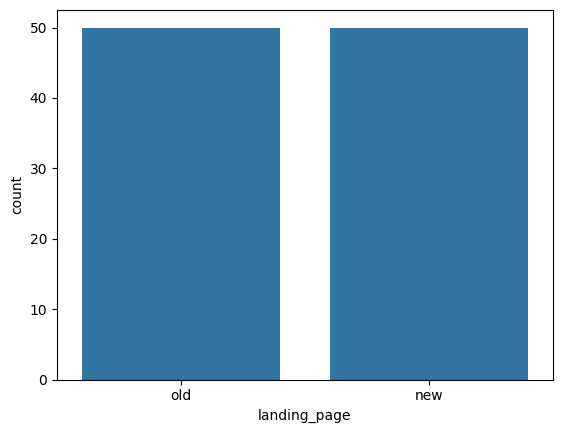

In [30]:
#plot the countplot for landing_page
sns.countplot(data=df,x='landing_page');

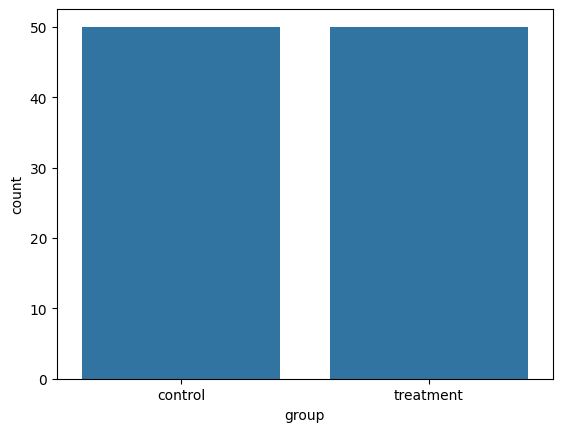

In [31]:
#plot the countplot for group
sns.countplot(data=df,x='group');

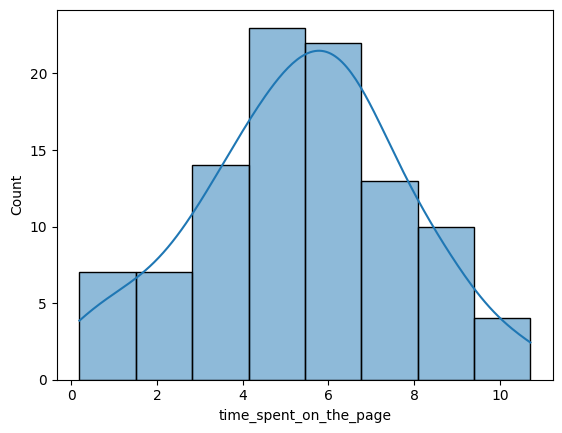

In [32]:
#plot the histogram for time_spent_on the page
sns.histplot(data=df,x='time_spent_on_the_page',kde=True);

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


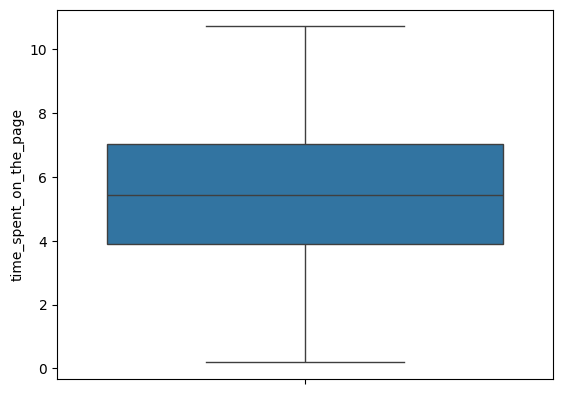

In [33]:
#plot the boxplot for time_spent_on the page
sns.boxplot(data=df,y='time_spent_on_the_page');

In [34]:
#find te state of the E-Expresss website
stateOfPage=df['landing_page'].unique()
stateOfPage

array(['old', 'new'], dtype=object)

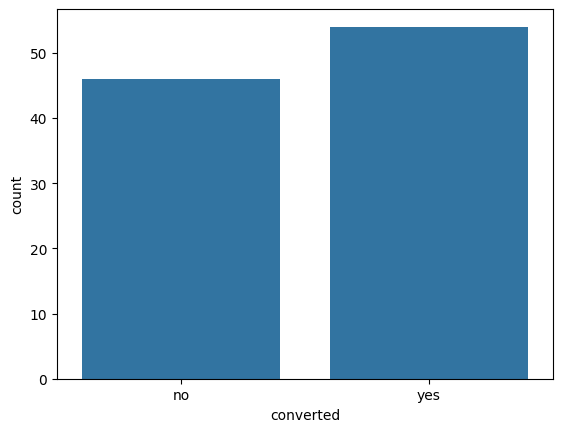

In [35]:
#plot the count for converted
sns.countplot(data=df,x='converted');

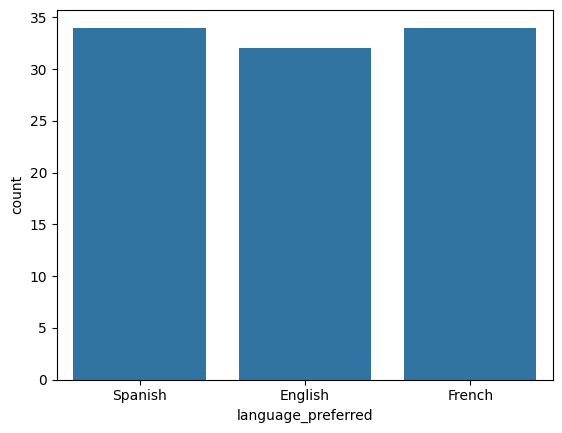

In [36]:
#plot the count for language_preferred
sns.countplot(data=df,x='language_preferred');

Text(0, 0.5, 'language_preferred')

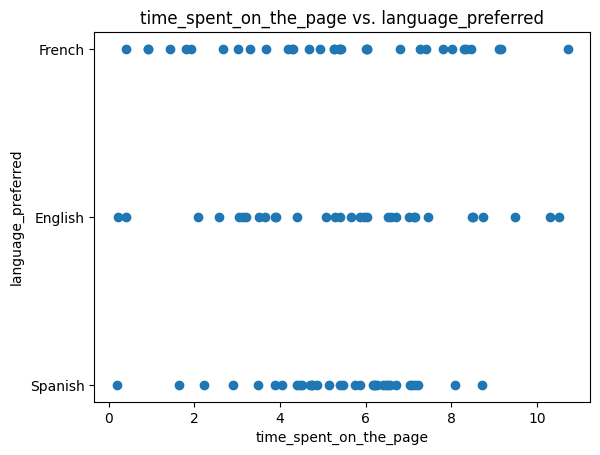

In [37]:
#Scatter plot the Time Spent & language_preferred
plt.scatter(df.time_spent_on_the_page,df.language_preferred)
plt.title('time_spent_on_the_page vs. language_preferred')
plt.xlabel('time_spent_on_the_page')
plt.ylabel('language_preferred')

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


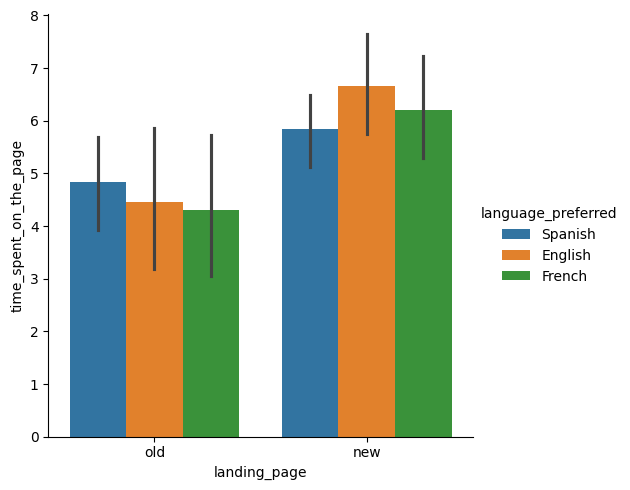

In [38]:
sns.catplot(data=df, x="landing_page", y="time_spent_on_the_page", hue="language_preferred", kind="bar");

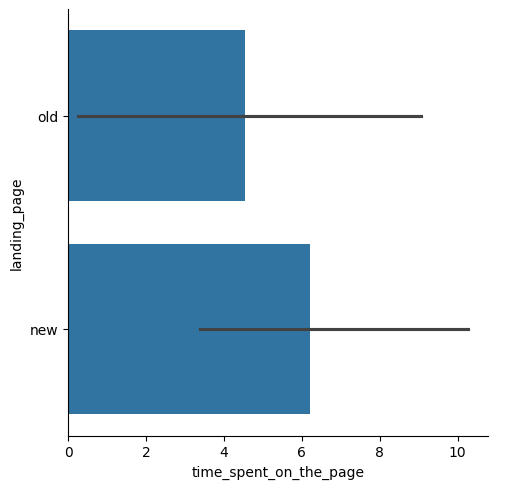

In [39]:
sns.catplot(data=df, x="time_spent_on_the_page", y="landing_page", errorbar=("pi", 95), kind="bar")

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


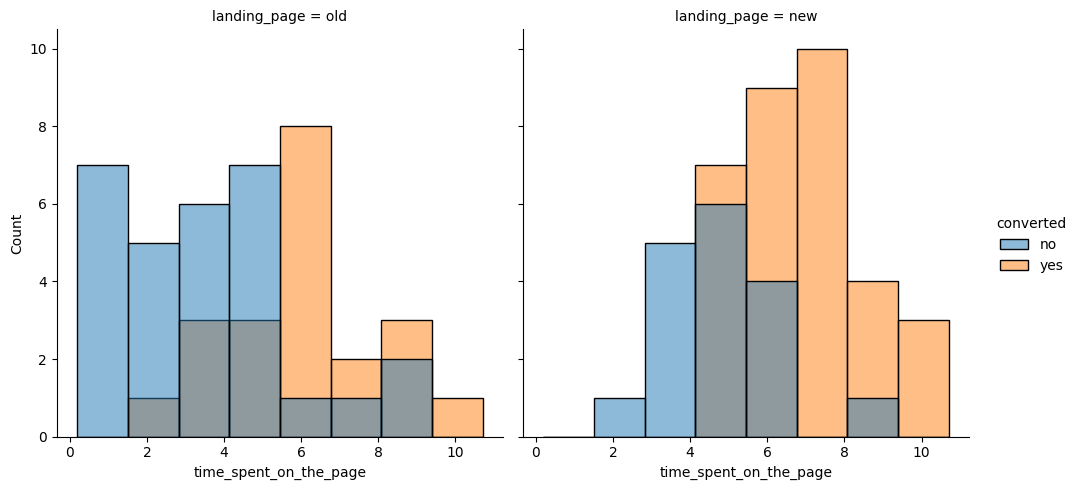

In [40]:
sns.displot(data=df, x="time_spent_on_the_page", col="landing_page", hue='converted');

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


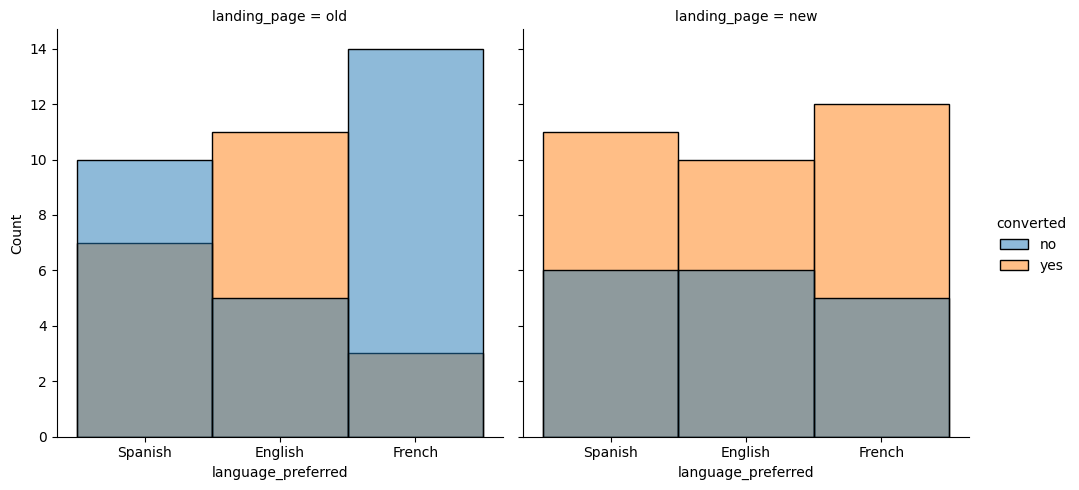

In [41]:
sns.displot(data=df, x="language_preferred", col="landing_page", hue='converted');

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When 

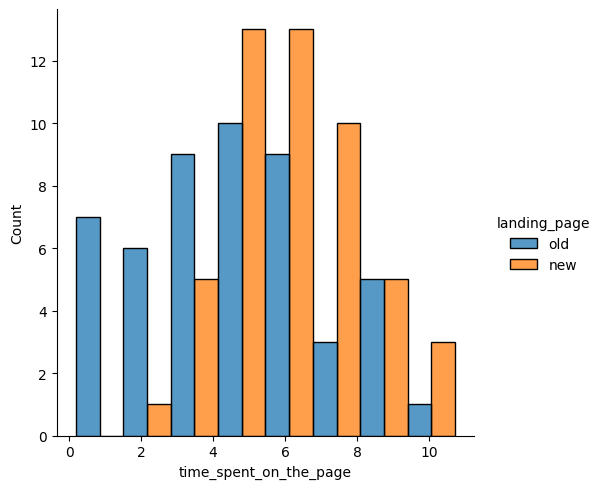

In [42]:
sns.displot(data=df, x="time_spent_on_the_page", hue="landing_page", multiple="dodge");

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


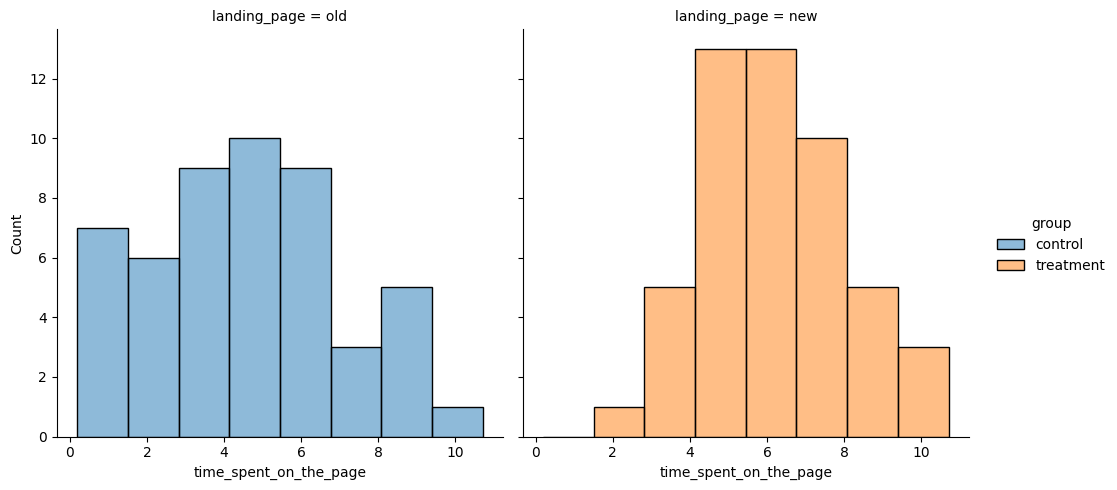

In [44]:
sns.displot(data=df, x="time_spent_on_the_page", col="landing_page", hue='group');

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


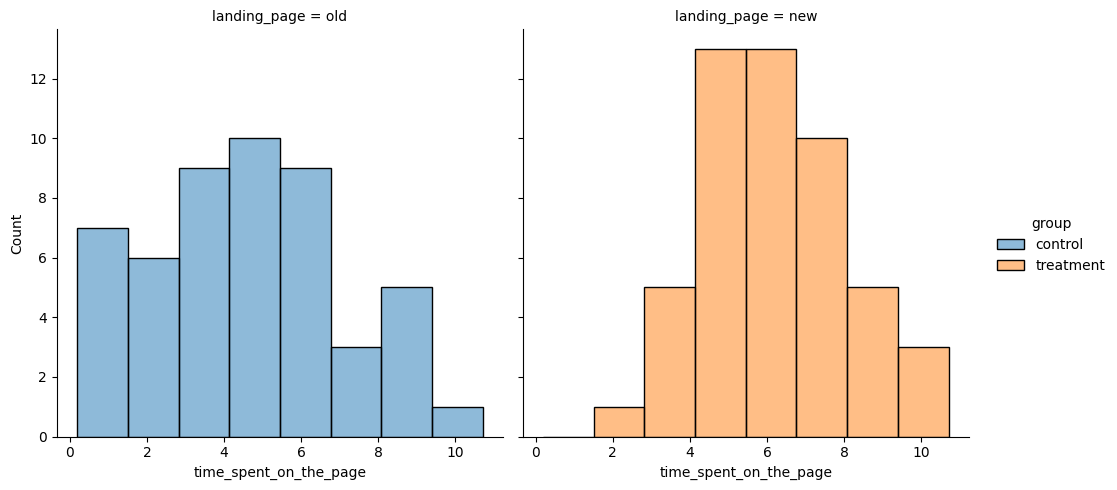

In [45]:
sns.displot(data=df, x="time_spent_on_the_page", col="landing_page", hue='group');

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


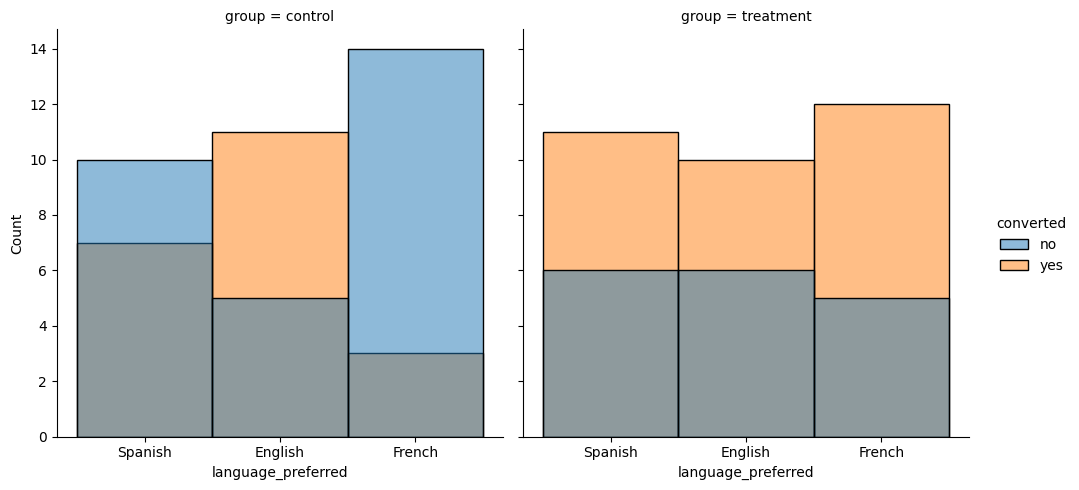

In [46]:
sns.displot(data=df, x="language_preferred", col="group", hue='converted');

#Insights based on EDA
(Key meaningful observations on individual variables and the relationship between variables)

Average time spent on the page is  5.38 minutes
Time spent on the page ranges between 0.19 minutes to 10.71 minutes.

Old version of landing page is at the top

Top language preferred is Spanish , out of the 3 languages, French, English & Spanish contents.

French is 2nd popular language preferred.

Number of Users getting converted to a subscriber of the news portal is higher than that of not getting converted to a subscriber.

The time_spent_on_the_page has increased in new landing page across 3 languages, French, English & Spanish contents.

New landing page has more numbers of users getting converted to a subscriber.

English language content users getting converted to a subscriber has not increased with new landing page in comparison to French & Spanish content users.



#Question 1:
The design team of the company has researched and created a new landing page that has a new outline & more relevant content compared to the old page.
Do the users spend more time on the new landing page than the old landing page?

Claim:
The users spend more time on the new landing page that the old landing page.

Population:
Users of E-news Express

Category:
landing_page

Parameter:
Mean time_spent_on_the_page

Test Statistic:
The test statistic is mean time_spent_on_the_page, from which we test the population parameter mu

Conditions for Testing
Randomly selected 100 users and dividing them equally into two groups.
Each group is of 50 users, each sample size is large(>30)

# Define null and alternative hypotheses
Define Claim as Hypothesis

H0: The mean of time_spent_on_the_page new landing page is equal to  the mean of time_spent_on_the_page average old landing page.

Ha:The mean of time_spent_on_the_page new landing page is greater than the mean of time_spent_on_the_page average old landing page.

As symbols:

H0: mu1=mu2

HA: mu1>mu2

where

mu1=Mean time_spent_on_the_page on new landing page

mu2=Mean time_spent_on_the_page on old landing page

#Select Appropriate test
Compare the sample means from 2 independent
populations when std devs are unknown
2-sample ind. t-test


The formulated hypotheses can be tested using a 2-sample ind. t-test test of independence of attributes

Test Type
Right Tailed

# Significance Level
alpha= 0.05(5%)

# Data Preparation



In [48]:
# See first 5 rows of data
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [49]:
#Calculate the average of time_spent_on_the_page for new landing page as mu1
dfNew= df.loc[df['landing_page']=='new']
mu1=dfNew['time_spent_on_the_page'].mean()

#Calculate the average of time_spent_on_the_page for old landing page as mu2
dfOld=df.loc[df['landing_page']=='old']
mu2=dfOld['time_spent_on_the_page'].mean()

#Calculate the standard deviation of time_spent_on_the_page for new landing page as sigma1
sigma1=dfNew['time_spent_on_the_page'].std()

#Calculate the standard deviation of time_spent_on_the_page for old landing page as sigma2
sigma2=dfOld['time_spent_on_the_page'].std()
print('mu1 : ',mu1,'mu2:',mu2)
print('sigma1 : ',sigma1,'sigma2:',sigma2)

mu1 :  6.2232 mu2: 4.532400000000001
sigma1 :  1.8170310387878263 sigma2: 2.581974849306046


# Calculate the p-value



In [53]:
#import the required functions
from scipy.stats import ttest_ind
#find the p value
test_stat,p_value= ttest_ind(dfNew['time_spent_on_the_page'],dfOld['time_spent_on_the_page'],equal_var=False,alternative='greater')
print('p_value is:',p_value)

p_value is: 0.0001392381225166549


# Compare the p-value with α



In [51]:
# print the conclusion based on p-value
if p_value < 0.05:
    print('As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print('As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')


As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.


In [60]:
#find critical value is 5% significal level
from scipy.stats import norm
critical_val=stats.norm.ppf(1-0.05)
critical_val

1.6448536269514722

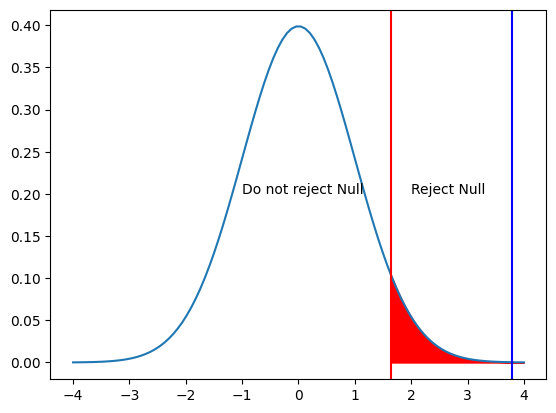

In [61]:
from scipy.stats import norm
#plotting the distribution  of z test statistics along with the test statistics
# plotting  the test statistics distribution indicating  the rejecction  and acceptance region
x=np.linspace(-4,4,100)
plt.plot(x,norm.pdf(x,0,1))
plt.axvline(x=critical_val,c='red')
x1=np.linspace(critical_val,4,50)
plt.fill_between(x1,norm.pdf(x1,0,1),color='red')
plt.annotate('Reject Null',(2,0.20))
plt.annotate('Do not reject Null',(-1,0.20))
plt.axvline(x=test_stat,c='blue')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


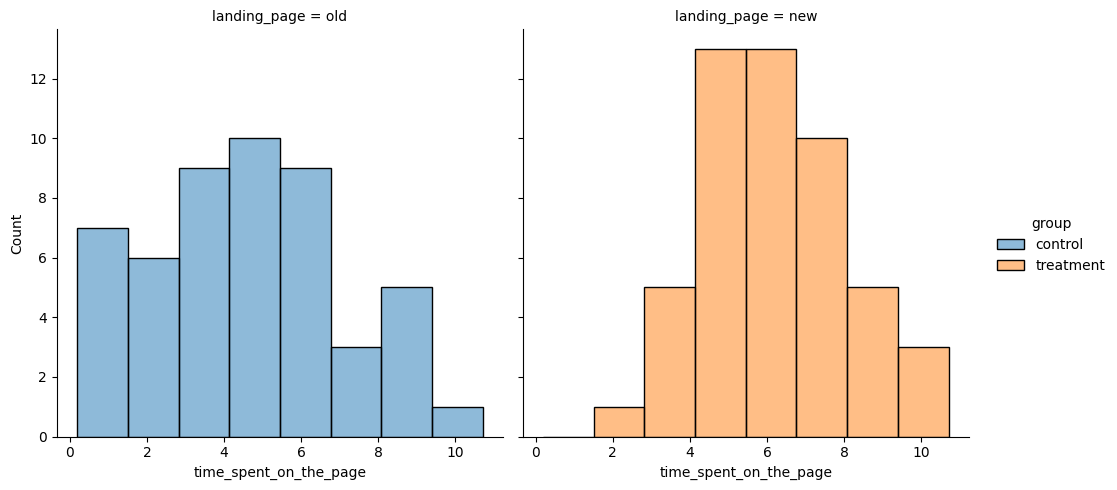

In [62]:
sns.displot(data=df, x="time_spent_on_the_page", col="landing_page", hue='group');

# Conclusion
Since the pvalue is < 0.05, we reject the null hypothesis. Hence, we have enough statistical evidence to say that the mean of time_spent_on_the_page new landing page is greater than the mean of time_spent_on_the_page average old landing page.

#Question 2:

Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page


Claim:
The users conversion rate(the proportion of users) for the new landing page is more than the conversion rate for the old landing page.

Population:
Users of E-news Express

Category:
landing_page
converted

Parameter:
proportion of users

Test Statistic: The conversion rate of users in the population

Conditions for Testing
Randomly selected 100 users and dividing them equally into two groups.
Each group is of 50 users, each sample size is large(>30)

# Define null and alternative hypotheses
Define Claim as Hypothesis

H0: The proportion of users getting converted to  subscribers from new landing page is equal to the proportion users getting converted to subscribers from old landing page.

Ha:The proportion of users getting converted to  subscribers from new landing page is greater than the proportion users getting converted to subscribers from old landing page.

As symbols:

H0: p1=p2

HA: p1>p2

where

p1=The proportion of users getting converted to  subscribers from new landing page

p2=The proportion users getting converted to subscribers from old landing page.

# Select Appropriate test

Two proportions z-test

Test Type

Right Tailed

# Significance Level
alpha= 0.05(5%)

#Data Preparation

In [63]:
# See first 5 rows of data
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [64]:
#find unique values in the dataset
values=df['converted'].unique()
values

array(['no', 'yes'], dtype=object)

In [65]:
#import the library
from statsmodels.stats.proportion import proportions_ztest
#Create the data frame with group and converted columns

dfGroup=df[['group','converted']]
#Create the individual data frame with group values
dfgroupControl=dfGroup.loc[dfGroup['group']=='control']
dfgroupTreatment=dfGroup.loc[dfGroup['group']=='treatment']
#Find the total number of rows in group
nob_col1 = dfgroupControl.shape[0]
nob_col2=dfgroupTreatment.shape[0]
#Create the individual data frame with converted as yes
dfControlConverted=dfgroupControl.loc[dfgroupControl['converted']=='yes']
dfControlTreatment=dfgroupTreatment.loc[dfgroupTreatment['converted']=='yes']

#Find the total counts of rows in group

count1=dfControlConverted.shape[0]
count2=dfControlTreatment.shape[0]

#Find the array for input to the proportion z test
count=[count1,count2]
nobs=[nob_col1,nob_col2]
print(count,nobs)

# Perform the two-proportion z-test
stat, pval = proportions_ztest(count, nobs)

# Print the results
print("Z-statistic:",stat)
print("P-value:",pval)


[21, 33] [50, 50]
Z-statistic: -2.4077170617153842
P-value: 0.016052616408112556


Compare p Value with alpha

In [66]:
# print the conclusion based on p-value
if pval < 0.05:
    print('As the p-value {pval} is less than the level of significance, we reject the null hypothesis.')
else:
    print('As the p-value {pval} is greater than the level of significance, we fail to reject the null hypothesis.')


As the p-value {pval} is less than the level of significance, we reject the null hypothesis.


/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When 

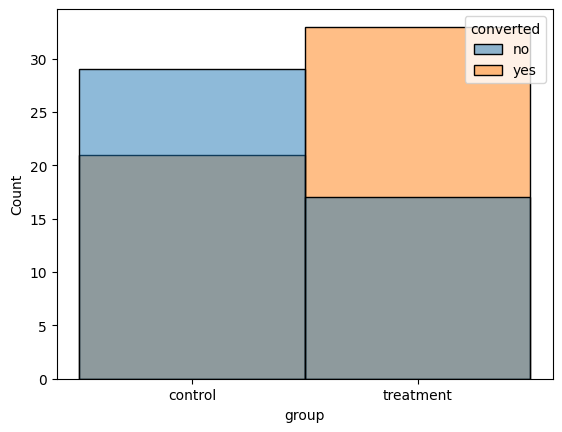

In [71]:
sns.histplot(data=df, x="group", hue="converted");

Conclusion:
Since the pvalue is < 0.05, we reject the null hypothesis.
 Hence, we have enough statistical evidence to say that the proportion of users getting converted to subscribers from new landing page is greater than the proportion users getting converted to subscribers from old landing page.

#Question3:

Does the converted status depend on the preferred language?

Claim:
The users conversion rate is dependent on preferred language

Population:
Users of E-news Express

Category:
language_preferred
converted

Parameter:
conversion rate of users

Test Statistic:
Relationship between conversion rate and preferred langauages of users in the population

Conditions for Testing
Randomly selected 100 users and dividing them equally into two groups.
Each group is of 50 users, each sample size is large(>30)

# Define null and alternative hypotheses
Define Claim as Hypothesis

H0: The users conversion rate is independent on preferred language.

Ha:The users conversion rate is dependent on preferred language.


# Select Appropriate test

Chi-Square Test for Independence

# Significance Level
alpha= 0.05(5%)

#Data Preparation

In [86]:
# See first 5 rows of data
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [87]:
# Contigency table
cross_tab = pd.crosstab(df['language_preferred'], df['converted'],margins=True)
cross_tab

converted,no,yes,All
language_preferred,,,
English,11,21,32
French,19,15,34
Spanish,16,18,34
All,46,54,100


In [91]:
# import the chi2 library.
from scipy.stats import chi2_contingency
chi, p_value,dof,expected=chi2_contingency(cross_tab)
print('test statistics:',chi,'p_value:',p_value,'dof:',dof,'expected:',expected)

test statistics: 3.0930306905370837 p_value: 0.7970832186581234 dof: 6 expected: [[ 14.72  17.28  32.  ]
 [ 15.64  18.36  34.  ]
 [ 15.64  18.36  34.  ]
 [ 46.    54.   100.  ]]


Compare p Value with alpha

In [92]:
    # print the conclusion based on p-value
if p_value < 0.05:
      print('As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
      print('As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.


/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


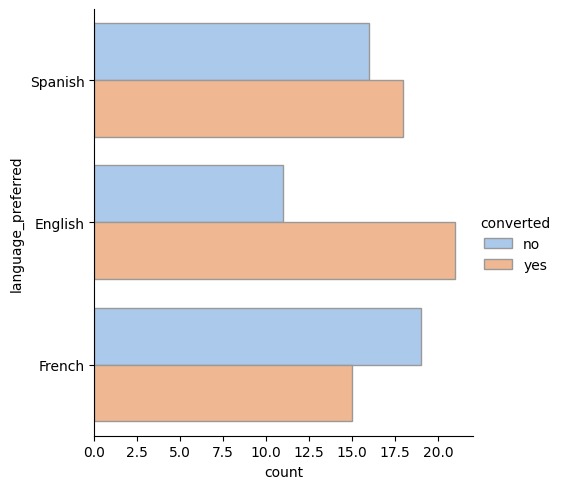

In [93]:
sns.catplot(
    data=df, y="language_preferred", hue="converted", kind="count",
    palette="pastel", edgecolor=".6",
);

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


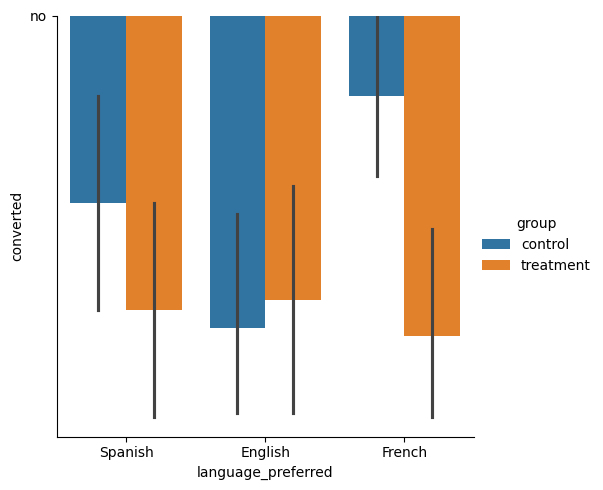

In [103]:
sns.catplot(data=df, x="language_preferred", y="converted", hue="group", kind="bar")

Conclusion:
Since the pvalue is > 0.05, we fail to reject the null hypothesis.
Hence the null hypothesis is true

H0: The users conversion rate is independent on preferred language.

#Question 4:

Is the mean time spent on the new page same for the different language users?

Claim:
The average time spent on the new page same for the different language users is same


Population:
Users of E-news Express


Category:
language_preferred
time_spent_on_the_page

Parameter:
means of time_spent_on_the_page for the different language users

Test Statistic:


Conditions for Testing
Randomly selected 100 users and dividing them equally into two groups.
Each group is of 50 users, each sample size is large(>30)

# Define null and alternative hypotheses
Define Claim as Hypothesis

H0: Means of  time_spent_on_the_page for the different language users are same

Ha:Atleast one of the mean on Means of  time_spent_on_the_page for the different language users is different


# Select Appropriate test

ANOVA Test

# Significance Level
alpha= 0.05(5%)

#Data Preparation

In [94]:
# See first 5 rows of data
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [95]:
#Suppose you want to test that whether there is any difference in means language_preferred. What will be the conclusion based on the p-value?
# Find the unique languages
langs=df['language_preferred'].unique()
print(langs)

['Spanish' 'English' 'French']


In [96]:

dfSpanish=df.loc[df['language_preferred']=='Spanish']
dfEnglish=df.loc[df['language_preferred']=='English']
dfFrench=df.loc[df['language_preferred']=='French']
A = dfSpanish['time_spent_on_the_page']
B = dfEnglish['time_spent_on_the_page']
C = dfFrench['time_spent_on_the_page']
results=stats.f_oneway(A,B,C)
print('result',results)
pvalue=results.pvalue
print(results.pvalue)

result F_onewayResult(statistic=0.1434343922124043, pvalue=0.8665610536012648)
0.8665610536012648


In [97]:
print(np.mean(A),np.mean(B),np.mean(C))

5.331764705882352 5.5590625 5.253235294117647


In [98]:
# print the conclusion based on p-value
if pvalue < 0.05:
    print('As the p-value {pvalue} is less than the level of significance, we reject the null hypothesis.')
else:
    print('As the p-value {pvalue} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value {pvalue} is greater than the level of significance, we fail to reject the null hypothesis.


/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future ve

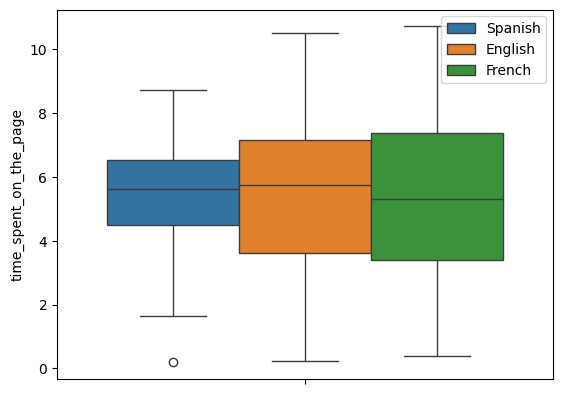

In [99]:
sns.boxplot(data=df,y='time_spent_on_the_page',hue='language_preferred');
plt.legend(loc=('upper right'))
plt.show()

Conclusion: As the p-value is greater than the level of significance, we fail to reject the null hypothesis.

H0: Means of time_spent_on_the_page for the different language users are same


#Conclusion and Business Recommendation
The E-news Express business should continue with the new landing page for the content provided by design team.
Users spend more time on the new landing page.
User visiting the new landing page are getting more likely to subscribe the E-news Express channel which is increase revenue for the company

English language contenton new landing page users getting converted to a subscriber has not increased with old landing page in comparison to French & Spanish content users for the same.
Hence the design team may bring more improvements to the English content for higher conversion rate for the English Content.

In [105]:
#@title Convert ipynb to HTML in Colab
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# download the html
files.download(file0[:-5]+"html")

IndexError: list index out of range